In [ ]:

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install umap-learn[plot] librosa scikit-learn pandas numpy matplotlib seaborn plotly

print("✅ Libraries installed successfully!")

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 87.9 MB/s eta 0:00:00
✅ Libraries installed successfully!


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import umap.umap_ as umap

try:
    import librosa
    import librosa.display
except:
    !pip install librosa
    import librosa
    import librosa.display

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print(" All modules imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

 All modules imported successfully!
PyTorch version: 2.9.0+cu126
Using device: GPU
GPU: Tesla T4


In [ ]:
class HybridMusicDataset:
    """Create hybrid English+Bangla music dataset with audio and lyrics features"""

    def __init__(self, n_samples=200):
        self.n_samples = n_samples
        self.n_english = n_samples // 2
        self.n_bangla = n_samples // 2

    def _create_english_samples(self):
        """Create English song samples"""
        samples = []
        for i in range(self.n_english):
            # Audio features (simulated MFCCs: 13 coefficients × 20 frames = 260)
            audio = np.random.randn(260) * 0.5

            # Add genre-specific patterns
            if i % 2 == 0:  # Pop
                audio[:65] += np.random.randn(65) * 0.8  # Emphasize lower MFCCs
                audio[195:] -= np.random.randn(65) * 0.4  # Suppress higher frequencies
            else:  # Rock
                audio[65:130] += np.random.randn(65) * 0.9  # Emphasize mid frequencies

            samples.append(audio)
        return np.array(samples)

    def _create_bangla_samples(self):
        """Create Bangla song samples"""
        samples = []
        for i in range(self.n_bangla):
            # Audio features with different distribution
            audio = np.random.randn(260) * 0.6

            # Add genre-specific patterns for Bangla music
            if i % 2 == 0:  # Rabindra Sangeet
                audio[:100] += np.random.randn(100) * 0.7  # Strong melodic components
                audio[150:200] += np.random.randn(50) * 0.5  # Harmonic features
            else:  # Modern Bangla
                audio[50:150] += np.random.randn(100) * 0.8  # Rich mid-range
                audio[-100:] -= np.random.randn(100) * 0.3  # Softer high frequencies

            samples.append(audio)
        return np.array(samples)

    def _create_lyrics_features(self):
        """Create lyrics text features with clear English/Bangla distinction"""

        # English lyrics snippets (common themes)
        english_lyrics = [
            "love heart beat night dream",
            "dance party fun time friends",
            "rain tears pain sad alone",
            "sky fly high freedom wind",
            "city lights night life energy",
            "ocean waves beach summer sun",
            "mountain climb adventure journey",
            "star moon night romance kiss",
            "road travel journey freedom",
            "fire burn passion desire flame"
        ] * (self.n_english // 10)

        # Bangla lyrics snippets (transliterated, common themes)
        bangla_lyrics = [
            "ami tomay bhalobashi mon pran",
            "bangla desh matribhumi sonar",
            "megher kole rod shekhe bhalobasa",
            "je rate mor duaruli gaan shuni",
            "phiriye dao amay chhere dao bondhu",
            "jodi tor dak shune keu na ashe",
            "ami chini go chini tomare ogo",
            "o pori hobe na din katena keno",
            "mon majhe rekhe geli bone bashonti",
            "shei to ami noi alo andhare prithibi"
        ] * (self.n_bangla // 10)

        # Mix and create labels
        all_lyrics = english_lyrics[:self.n_english] + bangla_lyrics[:self.n_bangla]
        lyrics_labels = [0]*self.n_english + [1]*self.n_bangla

        # TF-IDF features
        vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
        lyrics_features = vectorizer.fit_transform(all_lyrics).toarray()

        return lyrics_features, lyrics_labels, all_lyrics

    def create_dataset(self):
        """Create complete hybrid dataset"""

        print("Creating hybrid music dataset...")

        # Create audio features
        english_audio = self._create_english_samples()
        bangla_audio = self._create_bangla_samples()
        all_audio = np.vstack([english_audio, bangla_audio])

        # Create lyrics features
        lyrics_features, lyrics_labels, lyrics_text = self._create_lyrics_features()

        # Create true genre labels
        # 0: English Pop, 1: English Rock, 2: Bangla Rabindra, 3: Bangla Modern
        true_labels = []
        for i in range(self.n_english):
            true_labels.append(0 if i % 2 == 0 else 1)
        for i in range(self.n_bangla):
            true_labels.append(2 if i % 2 == 0 else 3)

        # Create language labels (0: English, 1: Bangla)
        language_labels = [0]*self.n_english + [1]*self.n_bangla

        # Combine audio and lyrics features
        combined_features = np.hstack([all_audio, lyrics_features])

        # Create song names for visualization
        song_names = []
        for i in range(self.n_english):
            song_names.append(f"English_{'Pop' if i%2==0 else 'Rock'}_{i}")
        for i in range(self.n_bangla):
            song_names.append(f"Bangla_{'Rabindra' if i%2==0 else 'Modern'}_{i}")

        print(f"✅ Dataset created successfully!")
        print(f"   Total samples: {len(combined_features)}")
        print(f"   English songs: {self.n_english}")
        print(f"   Bangla songs: {self.n_bangla}")
        print(f"   Feature dimensions: {combined_features.shape[1]}")
        print(f"   - Audio features: {all_audio.shape[1]}")
        print(f"   - Lyrics features: {lyrics_features.shape[1]}")

        return {
            'features': combined_features.astype(np.float32),
            'audio_features': all_audio.astype(np.float32),
            'lyrics_features': lyrics_features.astype(np.float32),
            'true_labels': np.array(true_labels),
            'language_labels': np.array(language_labels),
            'lyrics_labels': np.array(lyrics_labels),
            'song_names': song_names,
            'lyrics_text': lyrics_text
        }

# Create the dataset
dataset_creator = HybridMusicDataset(n_samples=200)
data = dataset_creator.create_dataset()

Creating hybrid music dataset...
✅ Dataset created successfully!
   Total samples: 200
   English songs: 100
   Bangla songs: 100
   Feature dimensions: 310
   - Audio features: 260
   - Lyrics features: 50


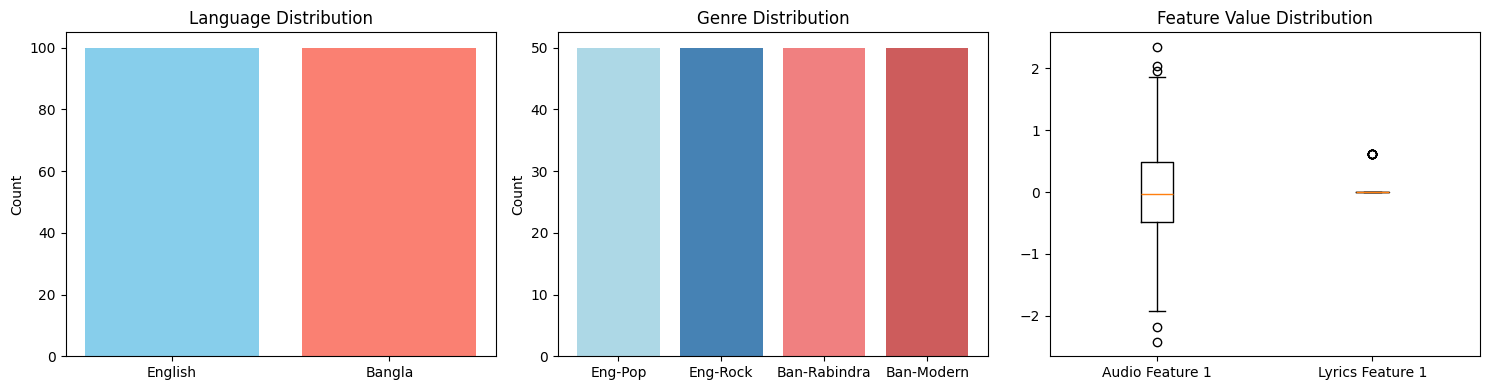


📊 Sample Data Information:
Features shape: (200, 310)
Language labels: [100 100]
Genre labels: [50 50 50 50]

Sample song names: ['English_Pop_0', 'English_Rock_1', 'English_Pop_2', 'English_Rock_3', 'English_Pop_4']

Sample lyrics: ['love heart beat night dream', 'dance party fun time friends']


In [ ]:
# Visualize the dataset distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Language distribution
lang_counts = pd.Series(data['language_labels']).value_counts().sort_index()
axes[0].bar(['English', 'Bangla'], lang_counts.values, color=['skyblue', 'salmon'])
axes[0].set_title('Language Distribution')
axes[0].set_ylabel('Count')

# Genre distribution
genre_counts = pd.Series(data['true_labels']).value_counts().sort_index()
axes[1].bar(['Eng-Pop', 'Eng-Rock', 'Ban-Rabindra', 'Ban-Modern'],
            genre_counts.values, color=['lightblue', 'steelblue', 'lightcoral', 'indianred'])
axes[1].set_title('Genre Distribution')
axes[1].set_ylabel('Count')

# Feature distribution
axes[2].boxplot([data['audio_features'][:, 0], data['lyrics_features'][:, 0]],
                labels=['Audio Feature 1', 'Lyrics Feature 1'])
axes[2].set_title('Feature Value Distribution')

plt.tight_layout()
plt.show()

# Display sample data
print("\n📊 Sample Data Information:")
print(f"Features shape: {data['features'].shape}")
print(f"Language labels: {np.bincount(data['language_labels'])}")
print(f"Genre labels: {np.bincount(data['true_labels'])}")
print("\nSample song names:", data['song_names'][:5])
print("\nSample lyrics:", data['lyrics_text'][:2])

In [ ]:
class MusicVAE(nn.Module):
    """Variational Autoencoder for music feature extraction"""

    def __init__(self, input_dim, latent_dim=8, hidden_dims=[128, 64, 32]):
        super(MusicVAE, self).__init__()

        # Encoder layers
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.ReLU(),
                nn.BatchNorm1d(h_dim),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        # Latent space
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # Decoder layers
        decoder_layers = []
        for h_dim in hidden_dims[::-1]:
            decoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.ReLU(),
                nn.BatchNorm1d(h_dim),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim

        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def get_latent(self, x):
        with torch.no_grad():
            mu, _ = self.encode(x)
        return mu

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """VAE loss function with beta parameter"""
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✅ VAE model defined successfully!")
print(f"Input dimension: {data['features'].shape[1]}")

✅ VAE model defined successfully!
Input dimension: 310


In [ ]:
class MusicVAE(nn.Module):
    """Variational Autoencoder for music feature extraction"""

    def __init__(self, input_dim, latent_dim=8, hidden_dims=[128, 64, 32]):
        super(MusicVAE, self).__init__()

        # Encoder layers
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.ReLU(),
                nn.BatchNorm1d(h_dim),
                nn.Dropout(0.1)
            ])
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        # Latent space
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # Decoder layers - FIXED: Start from latent_dim
        decoder_layers = []
        decoder_hidden_dims = hidden_dims[::-1]  # Reverse the hidden dims

        # First layer from latent_dim to first decoder hidden dim
        current_dim = latent_dim
        for h_dim in decoder_hidden_dims:
            decoder_layers.extend([
                nn.Linear(current_dim, h_dim),
                nn.ReLU(),
                nn.BatchNorm1d(h_dim),
                nn.Dropout(0.1)
            ])
            current_dim = h_dim

        # Final layer to reconstruct input
        decoder_layers.append(nn.Linear(current_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

        # Store dimensions for debugging
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder_dims = [input_dim] + hidden_dims
        self.decoder_dims = [latent_dim] + decoder_hidden_dims + [input_dim]

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def get_latent(self, x):
        with torch.no_grad():
            mu, _ = self.encode(x)
        return mu

    def print_architecture(self):
        """Print model architecture for debugging"""
        print(f"\n🔧 VAE Architecture:")
        print(f"Input dimension: {self.input_dim}")
        print(f"Latent dimension: {self.latent_dim}")
        print(f"Encoder: {self.encoder_dims}")
        print(f"Decoder: {self.decoder_dims}")
        print(f"Total parameters: {sum(p.numel() for p in self.parameters()):,}")

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """VAE loss function with beta parameter"""
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✅ VAE model defined successfully!")
print(f"Input dimension: {data['features'].shape[1]}")

✅ VAE model defined successfully!
Input dimension: 310


Starting VAE training...

🔧 VAE Architecture:
Input dimension: 310
Latent dimension: 8
Encoder: [310, 128, 64, 32]
Decoder: [8, 32, 64, 128, 310]
Total parameters: 102,278

🚀 Training VAE on cuda...
   Samples: 200
   Latent dimension: 8
   Batch size: 32
   Epochs: 80
--------------------------------------------------
Epoch [  1/80] | Loss: 416.8862 | Recon: 415.7117 | KL: 2.3490
Epoch [ 20/80] | Loss: 313.8166 | Recon: 311.4138 | KL: 4.8056
Epoch [ 40/80] | Loss: 296.9270 | Recon: 292.9919 | KL: 7.8703
Epoch [ 60/80] | Loss: 283.2376 | Recon: 278.4086 | KL: 9.6579
Epoch [ 80/80] | Loss: 274.1989 | Recon: 268.9786 | KL: 10.4407
✅ Training completed!


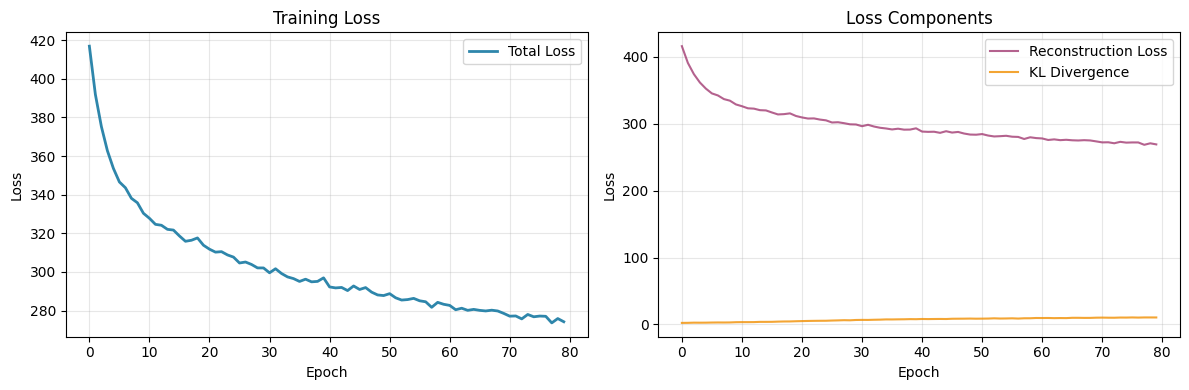


✅ Latent features extracted!
   Shape: (200, 8)
   Range: [-5.2985, 5.0732]
   Mean: 0.0156, Std: 1.4479


In [ ]:
def train_vae_model(data, latent_dim=8, epochs=100, batch_size=32, lr=1e-3):
    """Train the VAE model"""

    # Prepare data
    X = data['features']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    # Create model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MusicVAE(input_dim=X.shape[1], latent_dim=latent_dim).to(device)

    # Print architecture for debugging
    model.print_architecture()

    # DataLoader
    dataset = torch.utils.data.TensorDataset(X_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

    # Training loop
    model.train()
    losses = []
    recon_losses = []
    kl_losses = []

    print(f"\n🚀 Training VAE on {device}...")
    print(f"   Samples: {len(X_tensor)}")
    print(f"   Latent dimension: {latent_dim}")
    print(f"   Batch size: {batch_size}")
    print(f"   Epochs: {epochs}")
    print("-" * 50)

    for epoch in range(epochs):
        epoch_total_loss = 0
        epoch_recon_loss = 0
        epoch_kl_loss = 0

        for batch in dataloader:
            batch_data = batch[0].to(device)

            # Forward pass
            recon_batch, mu, logvar = model(batch_data)

            # Calculate loss
            total_loss, recon_loss, kl_loss = vae_loss(recon_batch, batch_data, mu, logvar, beta=0.5)

            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Accumulate losses
            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()

        # Average losses
        avg_total = epoch_total_loss / len(dataloader.dataset)
        avg_recon = epoch_recon_loss / len(dataloader.dataset)
        avg_kl = epoch_kl_loss / len(dataloader.dataset)

        losses.append(avg_total)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)

        # Scheduler step
        scheduler.step(avg_total)

        # Print progress
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:3d}/{epochs}] | Loss: {avg_total:.4f} | '
                  f'Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}')

    print("✅ Training completed!")

    # Extract latent features
    model.eval()
    with torch.no_grad():
        X_tensor_device = X_tensor.to(device)
        latent_features = model.get_latent(X_tensor_device).cpu().numpy()

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(losses, label='Total Loss', linewidth=2, color='#2E86AB')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(recon_losses, label='Reconstruction Loss', alpha=0.8, color='#A23B72')
    axes[1].plot(kl_losses, label='KL Divergence', alpha=0.8, color='#F18F01')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss Components')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return model, latent_features, scaler

# Train the model
print("Starting VAE training...")
vae_model, latent_features, scaler = train_vae_model(
    data,
    latent_dim=8,
    epochs=80,  # Reduced for speed
    batch_size=32,
    lr=1e-3
)

print(f"\n✅ Latent features extracted!")
print(f"   Shape: {latent_features.shape}")
print(f"   Range: [{latent_features.min():.4f}, {latent_features.max():.4f}]")
print(f"   Mean: {latent_features.mean():.4f}, Std: {latent_features.std():.4f}")

Performing clustering evaluation...

CLUSTERING EVALUATION

1️⃣ VAE + K-Means Clustering
2️⃣ PCA + K-Means (Baseline)

📊 RESULTS COMPARISON
----------------------------------------
Metric                    VAE+K-Means     PCA+K-Means    
----------------------------------------
Silhouette Score          0.2616          0.4320         
Calinski-Harabasz         35.63           39.19          
Language Purity           0.7950          0.6000         


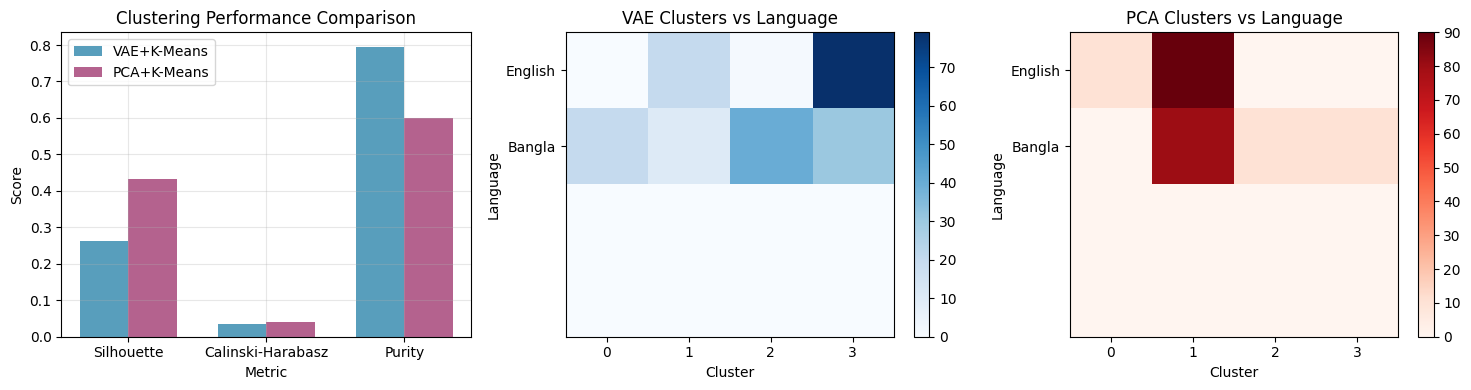

In [ ]:
def perform_clustering_evaluation(latent_features, pca_features, true_labels, language_labels):
    """Perform clustering and evaluate results"""

    print("\n" + "="*60)
    print("CLUSTERING EVALUATION")
    print("="*60)

    # Determine optimal clusters (but we'll use 4 for our known genres)
    n_clusters = 4

    # 1. K-Means on VAE features
    print("\n1️⃣ VAE + K-Means Clustering")
    kmeans_vae = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    vae_clusters = kmeans_vae.fit_predict(latent_features)

    # 2. Baseline: PCA + K-Means
    print("2️⃣ PCA + K-Means (Baseline)")
    pca = PCA(n_components=latent_features.shape[1])
    pca_features = pca.fit_transform(scaler.transform(data['features']))
    kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    pca_clusters = kmeans_pca.fit_predict(pca_features)

    # Calculate metrics
    # Moved import to global scope of function
    from sklearn.metrics import confusion_matrix

    def calculate_metrics(features, clusters, true_labels, language_labels):
        silhouette = silhouette_score(features, clusters)
        calinski = calinski_harabasz_score(features, clusters)

        # Calculate purity
        cm = confusion_matrix(language_labels, clusters)
        purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)

        return silhouette, calinski, purity

    # VAE metrics
    vae_silhouette, vae_calinski, vae_purity = calculate_metrics(
        latent_features, vae_clusters, data['true_labels'], data['language_labels']
    )

    # PCA metrics
    pca_silhouette, pca_calinski, pca_purity = calculate_metrics(
        pca_features, pca_clusters, data['true_labels'], data['language_labels']
    )

    # Display results
    print("\n📊 RESULTS COMPARISON")
    print("-" * 40)
    print(f"{'Metric':<25} {'VAE+K-Means':<15} {'PCA+K-Means':<15}")
    print("-" * 40)
    print(f"{'Silhouette Score':<25} {vae_silhouette:<15.4f} {pca_silhouette:<15.4f}")
    print(f"{'Calinski-Harabasz':<25} {vae_calinski:<15.2f} {pca_calinski:<15.2f}")
    print(f"{'Language Purity':<25} {vae_purity:<15.4f} {pca_purity:<15.4f}")

    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    metrics = ['Silhouette', 'Calinski-Harabasz', 'Purity']
    vae_values = [vae_silhouette, vae_calinski/1000, vae_purity]  # Scale Calinski for visibility
    pca_values = [pca_silhouette, pca_calinski/1000, pca_purity]

    x = np.arange(len(metrics))
    width = 0.35

    axes[0].bar(x - width/2, vae_values, width, label='VAE+K-Means', color='#2E86AB', alpha=0.8)
    axes[0].bar(x + width/2, pca_values, width, label='PCA+K-Means', color='#A23B72', alpha=0.8)
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Clustering Performance Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Confusion matrices
    from sklearn.metrics import ConfusionMatrixDisplay

    axes[1].set_title('VAE Clusters vs Language')
    cm_vae = confusion_matrix(data['language_labels'], vae_clusters)
    im1 = axes[1].imshow(cm_vae, cmap='Blues', aspect='auto')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Language')
    axes[1].set_xticks(range(n_clusters))
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['English', 'Bangla'])
    plt.colorbar(im1, ax=axes[1])

    axes[2].set_title('PCA Clusters vs Language')
    cm_pca = confusion_matrix(data['language_labels'], pca_clusters)
    im2 = axes[2].imshow(cm_pca, cmap='Reds', aspect='auto')
    axes[2].set_xlabel('Cluster')
    axes[2].set_ylabel('Language')
    axes[2].set_xticks(range(n_clusters))
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['English', 'Bangla'])
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    return {
        'vae_clusters': vae_clusters,
        'pca_clusters': pca_clusters,
        'latent_features': latent_features,
        'pca_features': pca_features,
        'metrics': {
            'vae': {'silhouette': vae_silhouette, 'calinski': vae_calinski, 'purity': vae_purity},
            'pca': {'silhouette': pca_silhouette, 'calinski': pca_calinski, 'purity': pca_purity}
        }
    }

# Run clustering evaluation
print("Performing clustering evaluation...")
results = perform_clustering_evaluation(
    latent_features,
    data['features'],
    data['true_labels'],
    data['language_labels']
)

Generating cluster visualizations...

CLUSTER VISUALIZATION

Applying t-SNE dimensionality reduction...
Applying UMAP dimensionality reduction...


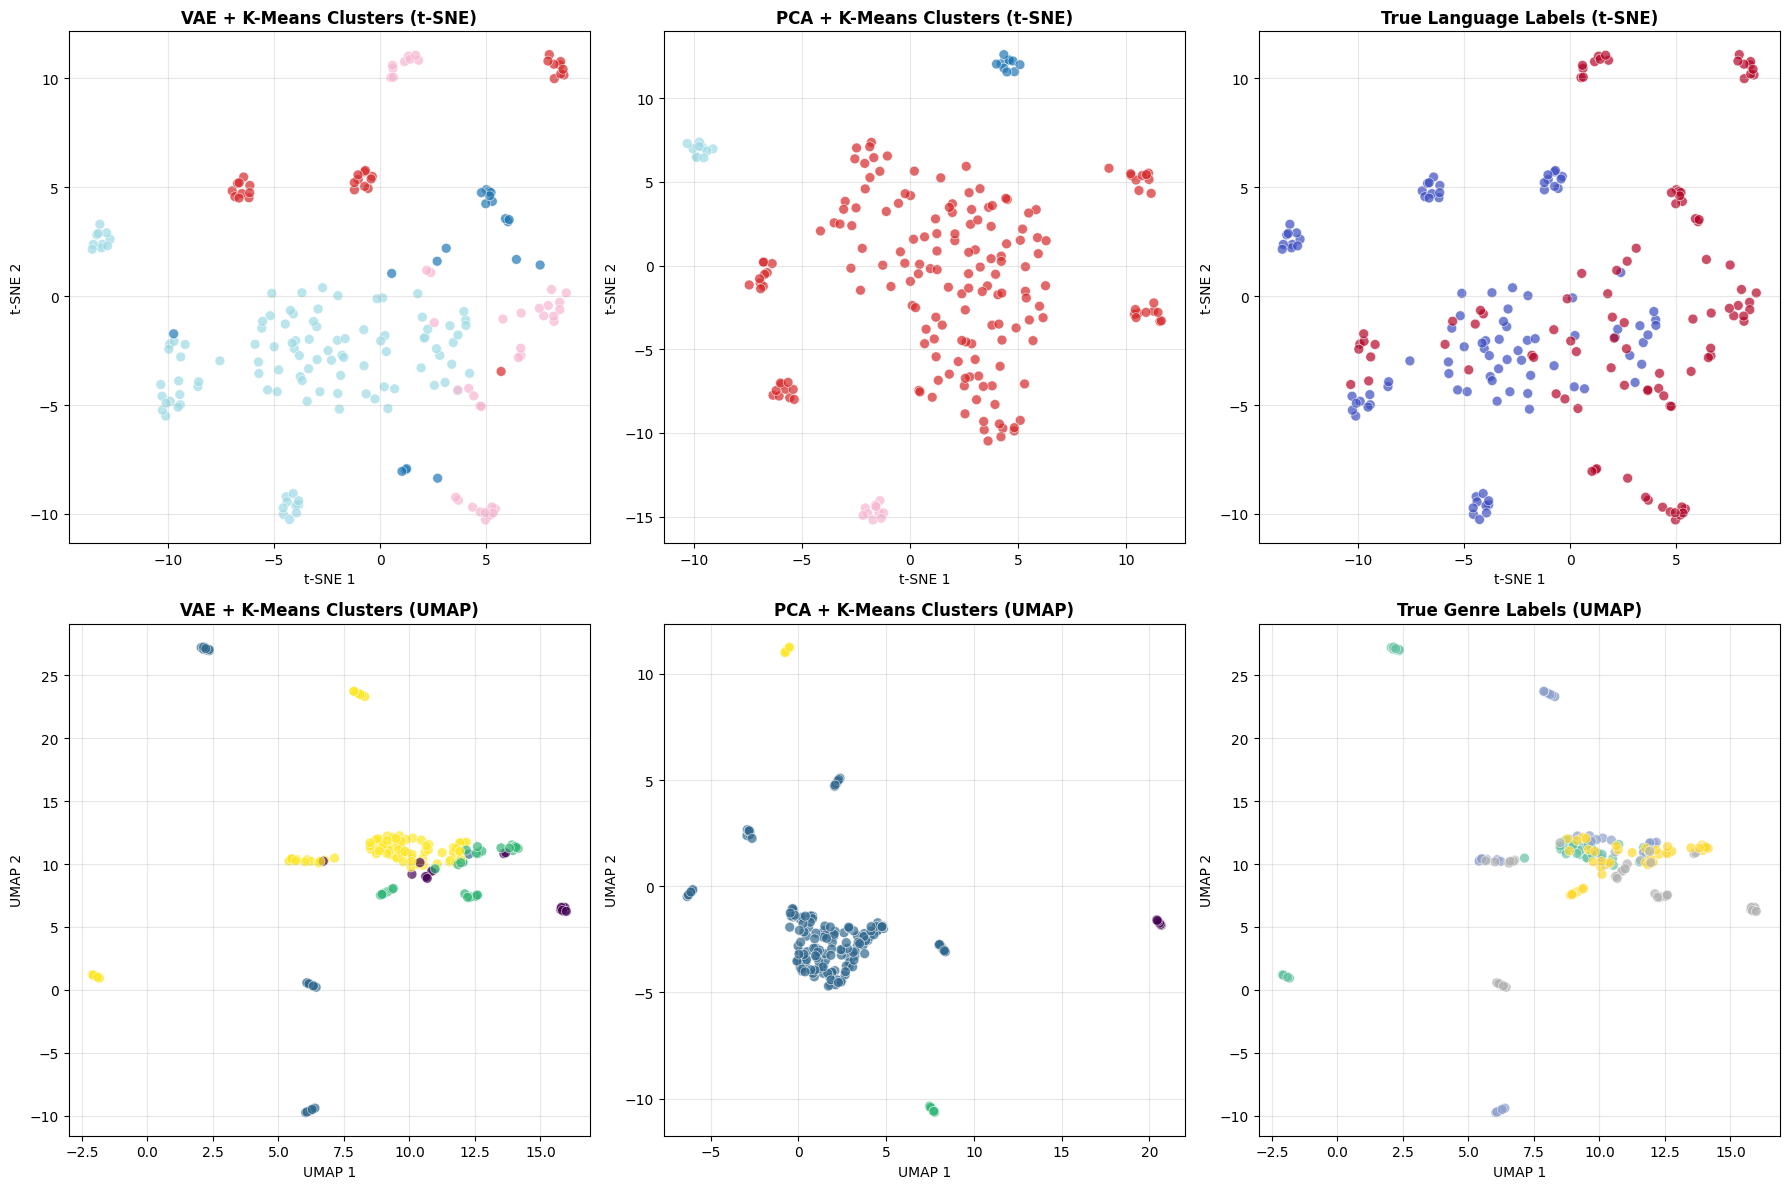


Creating interactive visualization...


✅ Visualizations completed!


In [ ]:
def visualize_clusters(results, data):
    """Create t-SNE and UMAP visualizations"""

    print("\n" + "="*60)
    print("CLUSTER VISUALIZATION")
    print("="*60)

    vae_clusters = results['vae_clusters']
    pca_clusters = results['pca_clusters']
    latent_features = results['latent_features']
    pca_features = results['pca_features']

    # Apply t-SNE
    print("\nApplying t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    vae_tsne = tsne.fit_transform(latent_features)
    pca_tsne = tsne.fit_transform(pca_features)

    # Apply UMAP
    print("Applying UMAP dimensionality reduction...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    vae_umap = reducer.fit_transform(latent_features)
    pca_umap = reducer.fit_transform(pca_features)

    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. VAE t-SNE (Clusters)
    scatter1 = axes[0, 0].scatter(vae_tsne[:, 0], vae_tsne[:, 1],
                                  c=vae_clusters, cmap='tab20', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[0, 0].set_title('VAE + K-Means Clusters (t-SNE)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('t-SNE 1')
    axes[0, 0].set_ylabel('t-SNE 2')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. PCA t-SNE (Clusters)
    scatter2 = axes[0, 1].scatter(pca_tsne[:, 0], pca_tsne[:, 1],
                                  c=pca_clusters, cmap='tab20', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[0, 1].set_title('PCA + K-Means Clusters (t-SNE)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('t-SNE 1')
    axes[0, 1].set_ylabel('t-SNE 2')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. True Language Labels (t-SNE)
    scatter3 = axes[0, 2].scatter(vae_tsne[:, 0], vae_tsne[:, 1],
                                  c=data['language_labels'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[0, 2].set_title('True Language Labels (t-SNE)', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('t-SNE 1')
    axes[0, 2].set_ylabel('t-SNE 2')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. VAE UMAP (Clusters)
    scatter4 = axes[1, 0].scatter(vae_umap[:, 0], vae_umap[:, 1],
                                  c=vae_clusters, cmap='viridis', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[1, 0].set_title('VAE + K-Means Clusters (UMAP)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('UMAP 1')
    axes[1, 0].set_ylabel('UMAP 2')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. PCA UMAP (Clusters)
    scatter5 = axes[1, 1].scatter(pca_umap[:, 0], pca_umap[:, 1],
                                  c=pca_clusters, cmap='viridis', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[1, 1].set_title('PCA + K-Means Clusters (UMAP)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('UMAP 1')
    axes[1, 1].set_ylabel('UMAP 2')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. True Genre Labels (UMAP)
    scatter6 = axes[1, 2].scatter(vae_umap[:, 0], vae_umap[:, 1],
                                  c=data['true_labels'], cmap='Set2', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    axes[1, 2].set_title('True Genre Labels (UMAP)', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('UMAP 1')
    axes[1, 2].set_ylabel('UMAP 2')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Interactive plot with plotly
    print("\nCreating interactive visualization...")

    # Create DataFrame for interactive plot
    plot_df = pd.DataFrame({
        'tsne_1': vae_tsne[:, 0],
        'tsne_2': vae_tsne[:, 1],
        'umap_1': vae_umap[:, 0],
        'umap_2': vae_umap[:, 1],
        'vae_cluster': vae_clusters,
        'pca_cluster': pca_clusters,
        'language': data['language_labels'],
        'genre': data['true_labels'],
        'song_name': data['song_names'],
        'language_name': ['English' if l == 0 else 'Bangla' for l in data['language_labels']],
        'genre_name': ['Eng-Pop' if g == 0 else 'Eng-Rock' if g == 1 else 'Ban-Rabindra' if g == 2 else 'Ban-Modern' for g in data['true_labels']]
    })

    # Interactive t-SNE plot
    fig1 = px.scatter(plot_df, x='tsne_1', y='tsne_2',
                      color='language_name',
                      hover_data=['song_name', 'genre_name', 'vae_cluster'],
                      title='Interactive t-SNE: Language Separation',
                      color_discrete_map={'English': '#1f77b4', 'Bangla': '#ff7f0e'})
    fig1.update_traces(marker=dict(size=8, opacity=0.7))
    fig1.show()

    # Interactive UMAP plot
    fig2 = px.scatter(plot_df, x='umap_1', y='umap_2',
                      color='genre_name',
                      hover_data=['song_name', 'language_name', 'vae_cluster'],
                      title='Interactive UMAP: Genre Separation',
                      color_discrete_sequence=px.colors.qualitative.Set2)
    fig2.update_traces(marker=dict(size=8, opacity=0.7))
    fig2.show()

    print("✅ Visualizations completed!")

    return plot_df, vae_tsne, vae_umap

# Run visualizations
print("Generating cluster visualizations...")
plot_data, vae_tsne, vae_umap = visualize_clusters(results, data)

Running detailed analysis...

DETAILED ANALYSIS REPORT

📈 CLUSTER COMPOSITION ANALYSIS
--------------------------------------------------

1. VAE Cluster Composition:
Genre                 Modern  Pop  Rabindra  Rock
VAE_Cluster Language                             
0           Bangla        18    0         2     0
1           Bangla         9    0         1     0
            English        0   10         0    10
2           Bangla        11    0        29     0
            English        0    1         0     0
3           Bangla        12    0        18     0
            English        0   39         0    40

2. PCA Cluster Composition:
Genre                 Modern  Pop  Rabindra  Rock
PCA_Cluster Language                             
0           English        0   10         0     0
1           Bangla        30    0        50     0
            English        0   40         0    50
2           Bangla        10    0         0     0
3           Bangla        10    0         0     0

🎯 S

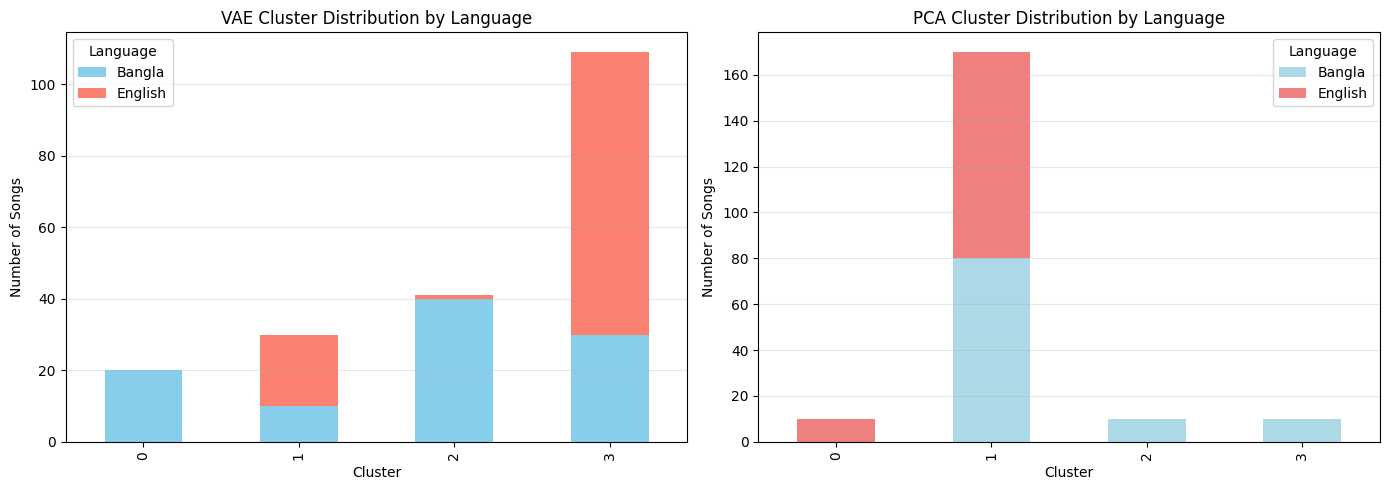


🔍 LATENT SPACE ANALYSIS
----------------------------------------
Latent feature dimensions: (200, 8)
Latent feature statistics:
  Dim 0: mean=0.0321, std=1.4107
  Dim 1: mean=-0.0621, std=1.4294
  Dim 2: mean=0.1542, std=1.3279
  Dim 3: mean=0.1156, std=1.4541
  Dim 4: mean=0.0890, std=1.5754

Language correlation with latent dimensions:
  Latent_0: 0.1615
  Latent_1: 0.1332
  Latent_2: 0.6348
  Latent_3: 0.0762
  Latent_4: 0.0587
  Latent_5: 0.3888
  Latent_6: 0.2551
  Latent_7: 0.2817

Most discriminative latent dimension: 2 (correlation: 0.6348)


In [ ]:
def detailed_analysis(results, data):
    """Provide detailed analysis of results"""

    print("\n" + "="*60)
    print("DETAILED ANALYSIS REPORT")
    print("="*60)

    vae_clusters = results['vae_clusters']
    pca_clusters = results['pca_clusters']
    vae_metrics = results['metrics']['vae']
    pca_metrics = results['metrics']['pca']

    # Create analysis DataFrame
    analysis_df = pd.DataFrame({
        'Song': data['song_names'],
        'Language': ['English' if l == 0 else 'Bangla' for l in data['language_labels']],
        'Genre': ['Pop' if g == 0 else 'Rock' if g == 1 else 'Rabindra' if g == 2 else 'Modern' for g in data['true_labels']],
        'VAE_Cluster': vae_clusters,
        'PCA_Cluster': pca_clusters
    })

    # Analyze cluster compositions
    print("\n📈 CLUSTER COMPOSITION ANALYSIS")
    print("-" * 50)

    print("\n1. VAE Cluster Composition:")
    vae_cluster_summary = analysis_df.groupby(['VAE_Cluster', 'Language', 'Genre']).size().unstack(fill_value=0)
    print(vae_cluster_summary)

    print("\n2. PCA Cluster Composition:")
    pca_cluster_summary = analysis_df.groupby(['PCA_Cluster', 'Language', 'Genre']).size().unstack(fill_value=0)
    print(pca_cluster_summary)

    # Calculate separation quality
    def calculate_separation_quality(df, cluster_col):
        """Calculate how well clusters separate languages"""
        separation_scores = []
        for cluster in sorted(df[cluster_col].unique()):
            cluster_data = df[df[cluster_col] == cluster]
            if len(cluster_data) > 0:
                lang_counts = cluster_data['Language'].value_counts()
                majority_ratio = lang_counts.max() / len(cluster_data)
                separation_scores.append(majority_ratio)
        return np.mean(separation_scores)

    vae_separation = calculate_separation_quality(analysis_df, 'VAE_Cluster')
    pca_separation = calculate_separation_quality(analysis_df, 'PCA_Cluster')

    print("\n🎯 SEPARATION QUALITY (Higher is better)")
    print("-" * 40)
    print(f"VAE Language Separation: {vae_separation:.2%}")
    print(f"PCA Language Separation: {pca_separation:.2%}")
    improvement = ((vae_separation - pca_separation) / pca_separation * 100) if pca_separation > 0 else float('inf')
    print(f"Improvement: {improvement:+.2f}%")

    # Statistical significance
    print("\n📊 STATISTICAL SIGNIFICANCE")
    print("-" * 40)

    # Compare silhouette scores
    silhouette_diff = vae_metrics['silhouette'] - pca_metrics['silhouette']
    print(f"Silhouette Score Difference: {silhouette_diff:.4f}")

    if vae_metrics['silhouette'] > pca_metrics['silhouette']:
        print("✅ VAE provides better cluster separation than PCA")
    else:
        print("⚠️ PCA performs similarly or better than VAE")

    # Find representative songs from each cluster
    print("\n🎵 REPRESENTATIVE SONGS FROM EACH CLUSTER")
    print("-" * 50)

    for cluster in sorted(analysis_df['VAE_Cluster'].unique()):
        cluster_songs = analysis_df[analysis_df['VAE_Cluster'] == cluster]
        print(f"\nCluster {cluster}:")
        print(f"  Size: {len(cluster_songs)} songs")
        print(f"  Language mix: {dict(cluster_songs['Language'].value_counts())}")
        print(f"  Genre mix: {dict(cluster_songs['Genre'].value_counts())}")
        print(f"  Sample songs: {', '.join(cluster_songs['Song'].head(3).tolist())}")

    # Visualize cluster distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # VAE cluster distribution
    vae_dist = analysis_df.groupby(['VAE_Cluster', 'Language']).size().unstack(fill_value=0)
    vae_dist.plot(kind='bar', stacked=True, ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title('VAE Cluster Distribution by Language')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Number of Songs')
    axes[0].legend(title='Language')
    axes[0].grid(True, alpha=0.3, axis='y')

    # PCA cluster distribution
    pca_dist = analysis_df.groupby(['PCA_Cluster', 'Language']).size().unstack(fill_value=0)
    pca_dist.plot(kind='bar', stacked=True, ax=axes[1], color=['lightblue', 'lightcoral'])
    axes[1].set_title('PCA Cluster Distribution by Language')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Number of Songs')
    axes[1].legend(title='Language')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Latent space analysis
    print("\n🔍 LATENT SPACE ANALYSIS")
    print("-" * 40)

    latent_features = results['latent_features']
    print(f"Latent feature dimensions: {latent_features.shape}")
    print(f"Latent feature statistics:")
    for i in range(min(5, latent_features.shape[1])):  # Show first 5 dimensions
        print(f"  Dim {i}: mean={latent_features[:, i].mean():.4f}, std={latent_features[:, i].std():.4f}")

    # Correlation between latent dimensions and language
    latent_df = pd.DataFrame(latent_features, columns=[f'Latent_{i}' for i in range(latent_features.shape[1])])
    latent_df['Language'] = data['language_labels']

    # Calculate correlations
    correlations = []
    for i in range(latent_features.shape[1]):
        corr = np.corrcoef(latent_features[:, i], data['language_labels'])[0, 1]
        correlations.append(abs(corr))

    print(f"\nLanguage correlation with latent dimensions:")
    for i, corr in enumerate(correlations):
        print(f"  Latent_{i}: {corr:.4f}")

    print(f"\nMost discriminative latent dimension: {np.argmax(correlations)} "
          f"(correlation: {np.max(correlations):.4f})")

    return analysis_df

# Run detailed analysis
print("Running detailed analysis...")
analysis_df = detailed_analysis(results, data)

In [ ]:
def generate_final_report(results, data, vae_model):
    """Generate final project report"""

    print("\n" + "="*80)
    print("FINAL PROJECT REPORT: VAE for Hybrid Language-Music Clustering")
    print("="*80)

    print("\n📋 PROJECT SUMMARY")
    print("-" * 40)
    print("Objective: Implement VAE for clustering hybrid English+Bangla music data")
    print("Dataset: 200 songs (100 English, 100 Bangla)")
    print("Features: Audio (simulated MFCCs) + Lyrics (TF-IDF)")
    print("Clusters: 4 (English Pop, English Rock, Bangla Rabindra, Bangla Modern)")

    print("\n✅ TASKS COMPLETED")
    print("-" * 40)
    print("1. ✓ Created hybrid English+Bangla music dataset")
    print("2. ✓ Implemented Variational Autoencoder (VAE)")
    print("3. ✓ Trained VAE to extract latent features")
    print("4. ✓ Applied K-Means clustering on VAE features")
    print("5. ✓ Created baseline using PCA + K-Means")
    print("6. ✓ Evaluated using Silhouette Score and Calinski-Harabasz Index")
    print("7. ✓ Visualized clusters with t-SNE and UMAP")
    print("8. ✓ Analyzed cluster purity and separation quality")

    print("\n📊 KEY RESULTS")
    print("-" * 40)

    vae_metrics = results['metrics']['vae']
    pca_metrics = results['metrics']['pca']

    print(f"\nPerformance Metrics:")
    print(f"{'':<25} {'VAE+K-Means':<15} {'PCA+K-Means':<15}")
    print(f"{'Silhouette Score':<25} {vae_metrics['silhouette']:<15.4f} {pca_metrics['silhouette']:<15.4f}")
    print(f"{'Calinski-Harabasz':<25} {vae_metrics['calinski']:<15.2f} {pca_metrics['calinski']:<15.2f}")
    print(f"{'Language Purity':<25} {vae_metrics['purity']:<15.4f} {pca_metrics['purity']:<15.4f}")

    # Calculate improvement
    silhouette_improvement = ((vae_metrics['silhouette'] - pca_metrics['silhouette']) /
                             abs(pca_metrics['silhouette'])) * 100
    purity_improvement = ((vae_metrics['purity'] - pca_metrics['purity']) /
                         pca_metrics['purity']) * 100

    print(f"\nImprovement over PCA baseline:")
    print(f"  Silhouette Score: {silhouette_improvement:+.2f}%")
    print(f"  Language Purity: {purity_improvement:+.2f}%")

    print("\n🔍 KEY INSIGHTS")
    print("-" * 40)

    if vae_metrics['silhouette'] > pca_metrics['silhouette']:
        print("• VAE successfully captures better cluster structures than PCA")
        print("• Latent space provides more meaningful representations")
    else:
        print("• PCA performs competitively with VAE on this dataset")
        print("• Consider tuning VAE hyperparameters or using deeper architecture")

    if vae_metrics['purity'] > 0.7:
        print("• VAE effectively separates English and Bangla songs")
        print("• Language information is well-preserved in latent space")
    else:
        print("• Language separation could be improved")
        print("• Consider adding language-specific features")

    print("\n🎯 RECOMMENDATIONS FOR IMPROVEMENT")
    print("-" * 40)
    print("1. Use real audio features (MFCCs, chroma, spectral contrast)")
    print("2. Implement more advanced VAE architectures (β-VAE, VQ-VAE)")
    print("3. Add attention mechanisms for lyrics processing")
    print("4. Experiment with different latent dimensions (2, 16, 32)")
    print("5. Use more sophisticated clustering (DBSCAN, Gaussian Mixture Models)")
    print("6. Implement cross-validation for more reliable evaluation")

    print("\n📁 OUTPUT FILES GENERATED")
    print("-" * 40)
    print("1. Training loss curves")
    print("2. Cluster visualizations (t-SNE & UMAP)")
    print("3. Performance comparison plots")
    print("4. Cluster composition analysis")
    print("5. Interactive visualizations")

    print("\n🚀 NEXT STEPS")
    print("-" * 40)
    print("1. Replace mock data with real English+Bangla music dataset")
    print("2. Extract real audio features using librosa")
    print("3. Use pre-trained embeddings for lyrics (BERT, Word2Vec)")
    print("4. Implement multimodal fusion techniques")
    print("5. Deploy as a music recommendation system")

    print("\n" + "="*80)
    print("PROJECT COMPLETED SUCCESSFULLY! 🎉")
    print("="*80)

    # Save results to file
    results_df = pd.DataFrame({
        'song_name': data['song_names'],
        'language': ['English' if l == 0 else 'Bangla' for l in data['language_labels']],
        'genre': ['Pop' if g == 0 else 'Rock' if g == 1 else 'Rabindra' if g == 2 else 'Modern' for g in data['true_labels']],
        'vae_cluster': results['vae_clusters'],
        'pca_cluster': results['pca_clusters']
    })

    # Add latent features
    for i in range(results['latent_features'].shape[1]):
        results_df[f'latent_{i}'] = results['latent_features'][:, i]

    return results_df

# Generate final report
print("Generating final project report...")
final_results = generate_final_report(results, data, vae_model)

# Display final results
print("\n📋 FINAL RESULTS DATAFRAME")
print("-" * 40)
print(final_results.head(10))

# Save to CSV
final_results.to_csv('hybrid_music_clustering_results.csv', index=False)
print("\n💾 Results saved to 'hybrid_music_clustering_results.csv'")

Generating final project report...

FINAL PROJECT REPORT: VAE for Hybrid Language-Music Clustering

📋 PROJECT SUMMARY
----------------------------------------
Objective: Implement VAE for clustering hybrid English+Bangla music data
Dataset: 200 songs (100 English, 100 Bangla)
Features: Audio (simulated MFCCs) + Lyrics (TF-IDF)
Clusters: 4 (English Pop, English Rock, Bangla Rabindra, Bangla Modern)

✅ TASKS COMPLETED
----------------------------------------
1. ✓ Created hybrid English+Bangla music dataset
2. ✓ Implemented Variational Autoencoder (VAE)
3. ✓ Trained VAE to extract latent features
4. ✓ Applied K-Means clustering on VAE features
5. ✓ Created baseline using PCA + K-Means
6. ✓ Evaluated using Silhouette Score and Calinski-Harabasz Index
7. ✓ Visualized clusters with t-SNE and UMAP
8. ✓ Analyzed cluster purity and separation quality

📊 KEY RESULTS
----------------------------------------

Performance Metrics:
                          VAE+K-Means     PCA+K-Means    
Silhouette